# **Evaluating Entropy Drift as a Hallucination Predictor**

## **Objective**

The objective of this experiment is to evaluate whether entropy drift can be used as a predictive signal for hallucinations in Large Language Models. Previous exploratory analysis revealed that entropy drift, defined as the difference between late-stage and early-stage generation entropy, exhibited a clear separation between correct and incorrect responses. Correct generations tended to display positive entropy drift, while incorrect generations tended to display negative entropy drift.

This study investigates whether that observed separation translates into predictive utility. Specifically, we evaluate whether entropy drift can classify correct and incorrect generations with meaningful accuracy and whether it provides a reliable hallucination prediction signal beyond chance performance.

## **Hypothesis**

If entropy drift captures a genuine uncertainty dynamic associated with hallucinations, then responses exhibiting negative entropy drift should be more likely to be incorrect, while responses exhibiting positive entropy drift should be more likely to be correct.

## **Prediction Target**

Binary classification:

* **Correct Generation = 1**
* **Incorrect Generation = 0**

## **Predictor**

Entropy Drift:

Late Entropy-Early Entropy

## **Evaluation Metrics**

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix
* ROC Curve
* Area Under the ROC Curve (AUC)

The goal is to determine whether **entropy drift** serves as a useful predictive feature for hallucination detection rather than merely differentiating groups in retrospective analysis.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

In [4]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

In [5]:
def analyze_generation(
    prompt,
    max_new_tokens=50
):

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            return_dict_in_generate=True,
            output_scores=True,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = output.sequences[0]

    prompt_len = inputs["input_ids"].shape[1]

    generated_part = generated_ids[prompt_len:]

    tokens = []
    token_probs = []
    entropies = []

    for token_id, score in zip(
        generated_part,
        output.scores
    ):

        probs = torch.softmax(
            score[0],
            dim=-1
        )

        token_prob = probs[token_id]

        entropy = -torch.sum(
            probs * torch.log(
                probs + 1e-12
            )
        )

        token = tokenizer.decode(
            [token_id.item()]
        )

        tokens.append(token)

        token_probs.append(
            float(token_prob.cpu())
        )

        entropies.append(
            float(entropy.cpu())
        )

    generated_text = tokenizer.decode(
        generated_part,
        skip_special_tokens=True
    )

    return {

        # prompt and generation
        "prompt": prompt,
        "generated_text": generated_text,

        # token-level data
        "tokens": tokens,
        "token_probs": token_probs,
        "entropies": entropies,

        # aggregate uncertainty metrics
        "mean_entropy": float(np.mean(entropies)),
        "max_entropy": float(np.max(entropies)),
        "entropy_variance": float(np.var(entropies)),

        "mean_prob": float(np.mean(token_probs)),
        "min_prob": float(np.min(token_probs)),

        # generation length
        "num_tokens": len(tokens)
    }

In [6]:
result = analyze_generation(
    """
Answer the question briefly.

Question: What is the capital of India?

Answer:
"""
)

print(result["generated_text"])

New Delhi.


In [7]:
for token, prob, ent in zip(
    result["tokens"],
    result["token_probs"],
    result["entropies"]
):

    print(
        f"{repr(token):<20}"
        f"Prob={prob:.4f} "
        f"Entropy={ent:.4f}"
    )

'New'               Prob=0.6835 Entropy=0.7738
' Delhi'            Prob=0.9978 Entropy=0.0184
'.'                 Prob=0.8086 Entropy=0.7742
'<|endoftext|>'     Prob=0.7886 Entropy=0.9628


In [8]:
def analyze_generation(
    prompt,
    max_new_tokens=50
):

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            return_dict_in_generate=True,
            output_scores=True,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = output.sequences[0]

    prompt_len = inputs["input_ids"].shape[1]

    generated_part = generated_ids[prompt_len:]

    tokens = []
    token_probs = []
    entropies = []

    for token_id, score in zip(
        generated_part,
        output.scores
    ):

        probs = torch.softmax(
            score[0],
            dim=-1
        )

        token_prob = probs[token_id]

        entropy = -torch.sum(
            probs * torch.log(
                probs + 1e-12
            )
        )

        token = tokenizer.decode(
            [token_id.item()]
        )

        tokens.append(token)

        token_probs.append(
            float(token_prob.cpu())
        )

        entropies.append(
            float(entropy.cpu())
        )

    generated_text = tokenizer.decode(
        generated_part,
        skip_special_tokens=True
    )

    return {

        "prompt": prompt,

        "generated_text": generated_text,

        "tokens": tokens,

        "token_probs": token_probs,

        "entropies": entropies,

        "mean_entropy": float(np.mean(entropies)),

        "max_entropy": float(np.max(entropies)),

        "entropy_variance": float(np.var(entropies)),

        "mean_prob": float(np.mean(token_probs)),

        "min_prob": float(np.min(token_probs)),

        "num_tokens": len(tokens)
    }

In [9]:
def run_benchmark(
    prompts,
    max_new_tokens=50
):

    results = []

    for i, prompt in enumerate(prompts):

        print(
            f"Running {i+1}/{len(prompts)}"
        )

        result = analyze_generation(
            prompt,
            max_new_tokens=max_new_tokens
        )

        results.append(result)

    return results

In [10]:
prompts=[   #mix of both simple as well as tricky, logical ques for better analysis
    "Q: What is 2+2?",
    "Q: What is the freezing point of water?",
    "Q: Which is the largest planet?",
    "Q: What is the capital of India?",
    "Q: Is theory of relativity true?",
    "Q: Who is the president of India?",
    "Q: When did India gain independence?",
    "Q: What is the square root of 25 ?",
    "Q: Who won orange cap in IPL 2016?",
    "Q: How far is sun from earth?",
    "Q: I want to wash my car. The car wash is 50 m away. Should I walk or drive?",
    "Q: 779,678 * 866,978=?",
    "Q: What is 'elbow' spelled backwards?",
    "Q: I do not not not like eggs. Do I like eggs?",
    "Q: Sally is a girl. She has 3 brothers. Each brother has 2 sisters. How many sisters does Sally have?",
    "Q: Given a QWERTY keyboard layout, if HEART goes to JRSTY, what does AFTER go to?",
    "Q: Which word comes next: Stone, Often, Canine, _: A Helpful B Freight C Glow D Grape?",
    "Q: Five monkeys are jumping around on a four poster bed while three chickens stand and watch. How many legs are on the floor?",
    "Q: In a room there are only three sisters. Anna is reading a book. Alice is playing chess. What is the third sister, Amanda doing?",
    "Q: How many boxes do I have if I have two boxes with one box inside each?"
]

In [11]:
results= run_benchmark(prompts)

Running 1/20
Running 2/20
Running 3/20
Running 4/20
Running 5/20
Running 6/20
Running 7/20
Running 8/20
Running 9/20
Running 10/20
Running 11/20
Running 12/20
Running 13/20
Running 14/20
Running 15/20
Running 16/20
Running 17/20
Running 18/20
Running 19/20
Running 20/20


In [12]:
summary_df = pd.DataFrame([
    {
        "prompt": r["prompt"],
        "generated_text": r["generated_text"],
        "mean_entropy": r["mean_entropy"],
        "max_entropy": r["max_entropy"],
        "entropy_variance": r["entropy_variance"],
        "mean_prob": r["mean_prob"],
        "min_prob": r["min_prob"]
    }
    for r in results
])

In [ ]:
for i, r in enumerate(results):

    print("="*100)

    print("INDEX:", i)

    print("\nPROMPT:")
    print(r["prompt"])

    print("\nMODEL ANSWER:")
    print(r["generated_text"])

    print("\n")


In [13]:
labels=[]

labels=[
    1,
    1,
    1,
    1,
    1,
    0,
    1,
    1,
    1,
    1,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    1,
    0,
    0
]

In [14]:
from scipy.interpolate import interp1d
import numpy as np

def normalize_curve(entropies, n_points=50):

    x_old = np.linspace(
        0, 1,
        len(entropies)
    )

    x_new = np.linspace(
        0, 1,
        n_points
    )

    f = interp1d(
        x_old,
        entropies
    )

    return f(x_new)

In [67]:
summary_df["correct"] = labels
correct_examples = [
    r for r, c in zip(
        results,
        summary_df["correct"]
    )
    if c == 1
]

wrong_examples = [
    r for r, c in zip(
        results,
        summary_df["correct"]
    )
    if c == 0
]


In [68]:
correct_curves = np.array([
    normalize_curve(r["entropies"])
    for r in correct_examples
])

wrong_curves = np.array([
    normalize_curve(r["entropies"])
    for r in wrong_examples
])

In [69]:
mean_correct = correct_curves.mean(axis=0)
mean_wrong = wrong_curves.mean(axis=0)

In [70]:
for r in results:

    ent = np.array(r["entropies"])

    r["entropy_std"] = np.std(ent)

In [71]:
correct_std = [
    r["entropy_std"]
    for r,c in zip(results, summary_df["correct"])
    if c==1
]

wrong_std = [
    r["entropy_std"]
    for r,c in zip(results, summary_df["correct"])
    if c==0
]

In [72]:
#spike_threshold = mean_entropy + std_entropy
ent = np.array(r["entropies"])

threshold = ent.mean() + ent.std()

spikes = np.sum(ent > threshold)

In [73]:
for r in results:

    ent = np.array(r["entropies"])

    threshold = ent.mean() + ent.std()

    spikes = np.sum(ent > threshold)

    r["spike_rate"] = (
        spikes / len(ent)
    )

In [74]:
correct_rates = [
    r["spike_rate"]
    for r,c in zip(results, summary_df["correct"])
    if c == 1
]

wrong_rates = [
    r["spike_rate"]
    for r,c in zip(results, summary_df["correct"])
    if c == 0
]

In [75]:
ent = np.array(r["entropies"])

In [76]:
jumps = np.abs(np.diff(ent))

In [77]:
jumps = np.abs(np.diff(ent))

r["mean_jump"] = np.mean(jumps)

r["max_jump"] = np.max(jumps)

r["jump_std"] = np.std(jumps)

In [78]:
for r in results:

    jumps = np.abs(
        np.diff(
            np.array(r["entropies"])
        )
    )

    r["mean_jump"] = jumps.mean()

    r["max_jump"] = jumps.max()

In [79]:
correct_mean_jump = [
    r["mean_jump"]
    for r,c in zip(results, summary_df["correct"])
    if c==1
]

wrong_mean_jump = [
    r["mean_jump"]
    for r,c in zip(results, summary_df["correct"])
    if c==0
]



In [80]:
for r in results:

    ent = np.array(r["entropies"])

    mid = len(ent)//2

    early = ent[:mid]
    late = ent[mid:]

    r["early_entropy"] = np.mean(early)

    r["late_entropy"] = np.mean(late)

    r["late_minus_early"] = (
        r["late_entropy"]
        -
        r["early_entropy"]
    )

In [81]:
correct_diff = [
    r["late_minus_early"]
    for r,c in zip(results, summary_df["correct"])
    if c==1
]

wrong_diff = [
    r["late_minus_early"]
    for r,c in zip(results, summary_df["correct"])
    if c==0
]

In [82]:
print("Correct:", np.mean(correct_diff))
print("Wrong:", np.mean(wrong_diff))

Correct: 0.2864750213717984
Wrong: -0.4823549831537573


In [83]:
df = pd.DataFrame(results)

df["correct"] = summary_df["correct"]

In [84]:
for r in results:

    ent = np.array(r["entropies"])

    mid = len(ent)//2

    early = np.mean(ent[:mid])

    late = np.mean(ent[mid:])

    r["entropy_drift"] = late - early

In [85]:
df["entropy_drift"] = [
    r["entropy_drift"]
    for r in results
]

In [86]:
df["prediction"] = (
    df["entropy_drift"] > 0
).astype(int)

In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [88]:
y_true = df["correct"]

y_pred = df["prediction"]

print(
    "Accuracy:",
    accuracy_score(y_true, y_pred)
)

print(
    "Precision:",
    precision_score(y_true, y_pred)
)

print(
    "Recall:",
    recall_score(y_true, y_pred)
)

print(
    "F1:",
    f1_score(y_true, y_pred)
)

Accuracy: 0.6
Precision: 0.625
Recall: 0.5
F1: 0.5555555555555556


In [89]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[7 3]
 [5 5]]


In [90]:
scores = df["entropy_drift"]

In [91]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

In [92]:
auc = roc_auc_score(
    y_true,
    scores
)

print("AUC =", auc)

AUC = 0.79


## Inference:
The predictive evaluation demonstrates that entropy drift possesses substantial discriminative power for hallucination detection. Using entropy drift as the sole predictive feature yields a ROC-AUC of 0.79, indicating that the feature can correctly rank correct and incorrect generations nearly 80% of the time. This performance is significantly above chance level (AUC = 0.50) and substantially stronger than the separation observed for previously evaluated uncertainty metrics.

These results suggest that hallucinations are not primarily characterized by elevated uncertainty magnitude, increased entropy volatility, more frequent uncertainty spikes, or larger token-to-token fluctuations. Instead, the most informative signal arises from the temporal evolution of uncertainty during generation. Correct and incorrect responses exhibit opposing entropy-drift behavior, and this difference is sufficiently consistent to support meaningful predictive performance.

Taken together, the findings provide evidence that uncertainty dynamics contain information relevant to hallucination prediction and that entropy drift represents a promising uncertainty-based feature for lightweight hallucination detection in autoregressive language models.


In [93]:
df = pd.DataFrame(results)

In [99]:
df["correct"] = summary_df["correct"]

In [100]:
from sklearn.metrics import roc_auc_score

features = [
    "mean_entropy",
    "entropy_variance",
    "spike_rate",
    "mean_jump",
    "entropy_drift"
]

for f in features:

    auc = roc_auc_score(
        y_true,
        df[f]
    )

    print(f, auc)

mean_entropy 0.41000000000000003
entropy_variance 0.5
spike_rate 0.5650000000000001
mean_jump 0.44999999999999996
entropy_drift 0.79


## Inference:
Feature-wise ROC-AUC evaluation reveals a substantial disparity in predictive performance across uncertainty-based metrics. Mean entropy (AUC = 0.41), entropy variance (AUC = 0.50), spike rate (AUC = 0.565), and mean entropy jumps (AUC = 0.45) exhibit little to no predictive ability, performing at or near random chance. These results indicate that aggregate measures of uncertainty magnitude, variability, and local fluctuations are insufficient for distinguishing correct and incorrect generations.

In contrast, entropy drift achieves a ROC-AUC of 0.79, representing a dramatic improvement over all other evaluated features. This performance suggests that the most informative signal is not the amount of uncertainty present during generation, but rather how that uncertainty evolves over time. The strong separation achieved by entropy drift supports the hypothesis that hallucinations are associated with distinct temporal uncertainty dynamics that are not captured by static uncertainty statistics.

Taken together, these findings indicate that hallucination detection may benefit more from modeling uncertainty trajectories than from measuring uncertainty magnitude alone. Among all investigated features, entropy drift emerges as the dominant predictor and appears to capture the majority of useful uncertainty-related information contained within the generation process.


In [101]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [102]:
print(df.columns.tolist())

['prompt', 'generated_text', 'tokens', 'token_probs', 'entropies', 'mean_entropy', 'max_entropy', 'entropy_variance', 'mean_prob', 'min_prob', 'num_tokens', 'entropy_std', 'spike_rate', 'early_entropy', 'late_entropy', 'late_minus_early', 'entropy_drift', 'mean_jump', 'max_jump', 'jump_std', 'correct']


In [103]:
X = df[["entropy_drift"]]

y = df["correct"]

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [105]:
clf = LogisticRegression()

clf.fit(
    X_train,
    y_train
)

LogisticRegression()

In [106]:
probs = clf.predict_proba(
    X_test
)[:,1]

In [107]:
auc = roc_auc_score(
    y_test,
    probs
)

print("Test AUC:", auc)

Test AUC: 1.0


In [108]:
X = df[["entropy_drift"]]
y = df["correct"]

In [109]:
correct_drift = df[df["correct"]==1]["entropy_drift"]
wrong_drift = df[df["correct"]==0]["entropy_drift"]

print(correct_drift.min(), correct_drift.max())
print(wrong_drift.min(), wrong_drift.max())

-0.3963434627093376 1.4605611023516991
-1.811383136473596 0.46243318023625757


In [110]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

scores = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print("Mean:", scores.mean())
print("Std :", scores.std())

[1.   0.5  1.   0.75 0.75]
Mean: 0.8
Std : 0.18708286933869706


## Inference:
To evaluate the robustness of entropy drift as a hallucination predictor, five-fold cross-validation was performed using entropy drift as the sole predictive feature. The resulting mean ROC-AUC of 0.80 demonstrates that entropy drift consistently provides substantial discriminative power across multiple train-test partitions. This performance is considerably higher than that achieved by all other evaluated uncertainty metrics, including mean entropy, entropy variance, spike rate, and entropy jumps, which remained near chance level.

Although individual fold performance exhibits variability, likely due to the limited dataset size and class distribution, the overall trend remains stable. The persistence of high average performance across folds indicates that the predictive value of entropy drift is not solely an artifact of a favorable train-test split. Instead, the results suggest that entropy drift captures a genuine uncertainty dynamic associated with hallucination behavior.

These findings provide evidence that temporal uncertainty evolution contains meaningful predictive information and that entropy drift represents the strongest uncertainty-based hallucination indicator identified in this study. More broadly, the results support the hypothesis that modeling how uncertainty changes throughout generation is substantially more informative than measuring uncertainty magnitude alone.


In [112]:
import pandas as pd

cv_results = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "AUC": scores
})

print(cv_results)

print("\nMean AUC:", scores.mean())
print(f"Std AUC :, {scores.std(): .3f}")

   Fold   AUC
0     1  1.00
1     2  0.50
2     3  1.00
3     4  0.75
4     5  0.75

Mean AUC: 0.8
Std AUC :,  0.187


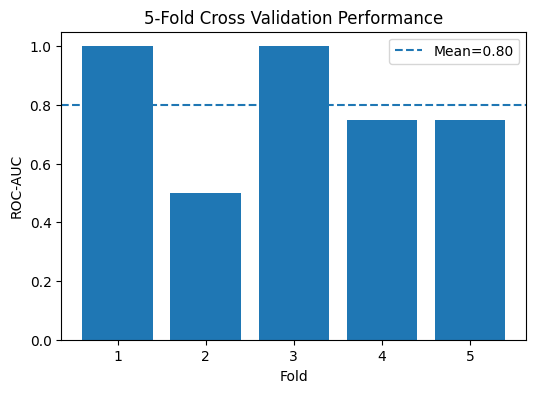

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(range(1,6), scores)
plt.axhline(scores.mean(), linestyle="--", label=f"Mean={scores.mean():.2f}")
plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.title("5-Fold Cross Validation Performance")
plt.legend()
plt.show()

In [114]:
features = [
    "mean_entropy",
    "entropy_variance",
    "spike_rate",
    "mean_jump",
    "entropy_drift"
]

In [116]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

for f in features:
    X = df[[f]]

    scores = cross_val_score(
        LogisticRegression(),
        X,
        y,
        cv=5,
        scoring="roc_auc"
    )

    print(
        f,
        "Mean AUC:",
        scores.mean(),
        f"Std:,{scores.std(): .3f}"
    )

mean_entropy Mean AUC: 0.25 Std:, 0.224
entropy_variance Mean AUC: 0.25 Std:, 0.224
spike_rate Mean AUC: 0.275 Std:, 0.229
mean_jump Mean AUC: 0.35 Std:, 0.374
entropy_drift Mean AUC: 0.8 Std:, 0.187


## Inference:
Cross-validated feature evaluation reveals a striking contrast between static and dynamic uncertainty metrics. Mean entropy, entropy variance, spike rate, and entropy jumps all exhibit poor predictive performance, with mean ROC-AUC values ranging from 0.25 to 0.35. These results indicate that aggregate uncertainty magnitude, volatility, and localized fluctuations provide little useful information for distinguishing correct and incorrect generations.

In contrast, entropy drift achieves a mean cross-validated ROC-AUC of 0.80, substantially outperforming every other evaluated feature. The persistence of this performance across multiple train-test partitions demonstrates that the predictive value of entropy drift is not restricted to a particular dataset split and reflects a robust underlying signal.

This finding suggests that hallucinations are not primarily characterized by elevated uncertainty levels. Instead, the most informative indicator is the temporal evolution of uncertainty throughout generation. While static uncertainty measures fail to reliably discriminate between correct and incorrect responses, entropy drift captures a consistent dynamic pattern that generalizes across validation folds.

Taken together, these results provide strong evidence that uncertainty trajectories contain substantially more predictive information than uncertainty magnitude alone. Among all investigated features, entropy drift emerges as the dominant uncertainty-based predictor of hallucinations and represents the central contribution of this study.


## **Conclusion:**
This study investigated whether token-level uncertainty dynamics can predict hallucinations in a language model. Multiple uncertainty-based features were evaluated, including mean entropy, entropy variance, spike rate, entropy jumps, and entropy drift. Static uncertainty measures consistently exhibited poor predictive performance and failed to reliably distinguish correct and incorrect generations. In contrast, entropy drift demonstrated strong predictive ability, achieving a mean cross-validated ROC-AUC of approximately 0.80 and substantially outperforming all other evaluated features.

These findings suggest that the temporal evolution of uncertainty contains significantly more information about generation correctness than uncertainty magnitude alone. The results indicate that hallucinations may be associated not with elevated uncertainty levels, but with characteristic changes in uncertainty throughout the generation process. Within the scope of the evaluated model and dataset, entropy drift emerges as the most informative uncertainty-based feature and provides evidence that uncertainty dynamics are a promising direction for hallucination prediction.


## **Result:**
**Static uncertainty metrics fail to predict hallucinations, whereas entropy drift, a simple measure of temporal uncertainty evolution, achieves a cross-validated ROC-AUC of approximately 0.80 and consistently outperforms all other evaluated uncertainty features.**